# Sentiment Analysis using SVM with BoW and TF-IDF

## CSE 4221 — Natural Language Processing Assignment

**Model:** Support Vector Machine (Linear)  
**Features:** Bag of Words (300) + TF-IDF (300)  
**Dataset:** IMDB Movie Review Dataset  
**Task:** Binary Sentiment Classification

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load Dataset

In [2]:
import gdown
url = 'https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI'
gdown.download(url, 'IMDB-Dataset.csv', quiet=False)

df = pd.read_csv('IMDB-Dataset.csv')
print(f'Shape: {df.shape}')
print(df['sentiment'].value_counts())
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed {duplicates} duplicates. New shape: {df.shape}')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI
To: /content/IMDB-Dataset.csv
100%|██████████| 66.2M/66.2M [00:00<00:00, 87.0MB/s]


Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Removed 418 duplicates. New shape: (49582, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
## 3. Text Preprocessing

In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print('Preprocessing...')
df['cleaned_review'] = df['review'].apply(preprocess_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print('Done.')

Preprocessing...
Done.


---
## 4. Train-Test Split (80:20)

In [4]:
X = df['cleaned_review']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 39665, Test: 9917


---
## 5. Feature Extraction

### 5a. Bag of Words (300 features)

In [5]:
bow_vectorizer = CountVectorizer(max_features=300)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
print(f'BoW shape: {X_train_bow.shape}')

BoW shape: (39665, 300)


### 5b. TF-IDF (300 features)

In [6]:
tfidf_vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(f'TF-IDF shape: {X_train_tfidf.shape}')

TF-IDF shape: (39665, 300)


---
## 6. Model Training & Evaluation

### 6a. SVM + BoW

In [7]:
svm_bow = LinearSVC(max_iter=2000, random_state=42, C=1.0)
svm_bow.fit(X_train_bow, y_train)
y_pred_bow = svm_bow.predict(X_test_bow)

acc_bow  = accuracy_score(y_test, y_pred_bow)
prec_bow = precision_score(y_test, y_pred_bow)
rec_bow  = recall_score(y_test, y_pred_bow)
f1_bow   = f1_score(y_test, y_pred_bow)

print('=' * 55)
print('  SVM + BoW — RESULTS')
print('=' * 55)
print(f'  Accuracy:  {acc_bow:.4f}')
print(f'  Precision: {prec_bow:.4f}')
print(f'  Recall:    {rec_bow:.4f}')
print(f'  F1-Score:  {f1_bow:.4f}')
print('=' * 55)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_bow, target_names=['Negative', 'Positive']))

  SVM + BoW — RESULTS
  Accuracy:  0.8137
  Precision: 0.8020
  Recall:    0.8348
  F1-Score:  0.8181

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81      4940
    Positive       0.80      0.83      0.82      4977

    accuracy                           0.81      9917
   macro avg       0.81      0.81      0.81      9917
weighted avg       0.81      0.81      0.81      9917



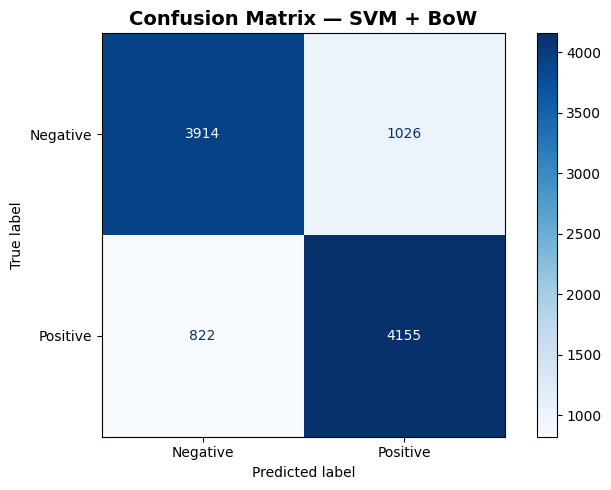

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_bow)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive']).plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix — SVM + BoW', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 6b. SVM + TF-IDF

In [9]:
svm_tfidf = LinearSVC(max_iter=2000, random_state=42, C=1.0)
svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = svm_tfidf.predict(X_test_tfidf)

acc_tfidf  = accuracy_score(y_test, y_pred_tfidf)
prec_tfidf = precision_score(y_test, y_pred_tfidf)
rec_tfidf  = recall_score(y_test, y_pred_tfidf)
f1_tfidf   = f1_score(y_test, y_pred_tfidf)

print('=' * 55)
print('  SVM + TF-IDF — RESULTS')
print('=' * 55)
print(f'  Accuracy:  {acc_tfidf:.4f}')
print(f'  Precision: {prec_tfidf:.4f}')
print(f'  Recall:    {rec_tfidf:.4f}')
print(f'  F1-Score:  {f1_tfidf:.4f}')
print('=' * 55)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))

  SVM + TF-IDF — RESULTS
  Accuracy:  0.8155
  Precision: 0.8062
  Recall:    0.8324
  F1-Score:  0.8191

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.80      0.81      4940
    Positive       0.81      0.83      0.82      4977

    accuracy                           0.82      9917
   macro avg       0.82      0.82      0.82      9917
weighted avg       0.82      0.82      0.82      9917



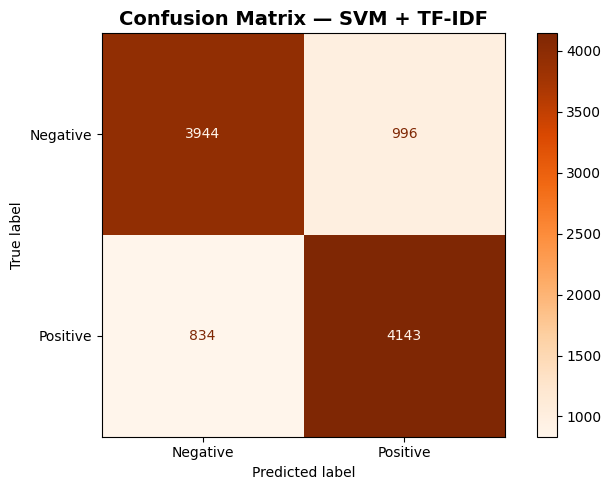

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_tfidf)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive']).plot(cmap='Oranges', ax=ax, values_format='d')
ax.set_title('Confusion Matrix — SVM + TF-IDF', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Comparison Table

In [11]:
comparison = pd.DataFrame({
    'Model': ['SVM + BoW', 'SVM + TF-IDF'],
    'Accuracy': [acc_bow, acc_tfidf],
    'Precision': [prec_bow, prec_tfidf],
    'Recall': [rec_bow, rec_tfidf],
    'F1-Score': [f1_bow, f1_tfidf]
})
print(comparison.to_string(index=False))

       Model  Accuracy  Precision   Recall  F1-Score
   SVM + BoW  0.813653   0.801969 0.834840  0.818074
SVM + TF-IDF  0.815468   0.806188 0.832429  0.819098


---
## 8. Analysis and Discussion

### Observations
- **TF-IDF** typically yields better results than raw **BoW** due to discriminative term weighting.
- **SVM**'s maximum-margin principle is well-suited for high-dimensional sparse text features.
- Bigrams in TF-IDF help capture short sentiment-bearing phrases.

### Limitations
- Both approaches remain bag-of-words — no semantic or contextual understanding.
- 300 features is restrictive; higher dimensionality could improve performance.
- Cannot model word order or long-range dependencies.